# Análise das Compras e Contratações Públicas e Diferenças Regionais

### **Problema:**

Como as compras e contratações públicas se distribuem entre 
diferentes regiões do Brasil e quais temas aparecem com maior 
frequência nos objetos dessas contratações?

### **Objetivo:**

Analisar as diferenças regionais nas contratações públicas, 
comparando a quantidade e os valores das compras entre diferentes 
Unidades da Federação (UFs), além de identificar os principais 
temas presentes nas descrições dos objetos das contratações.

In [1]:
# pip install requests pandas matplotlib -q

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
BASE_URL = "https://dadosabertos.compras.gov.br"

ENDPOINT_CONTRATACOES = "/modulo-contratacoes/1_consultarContratacoes_PNCP_14133"


url = BASE_URL + ENDPOINT_CONTRATACOES

print(url)

https://dadosabertos.compras.gov.br/modulo-contratacoes/1_consultarContratacoes_PNCP_14133


In [4]:
params = {
    "pagina": 1,
    "tamanhoPagina": 10,
    "dataPublicacaoPncpInicial": "2026-01-01",
    "dataPublicacaoPncpFinal": "2026-06-30",
    "codigoModalidade": 5
}

params

{'pagina': 1,
 'tamanhoPagina': 10,
 'dataPublicacaoPncpInicial': '2026-01-01',
 'dataPublicacaoPncpFinal': '2026-06-30',
 'codigoModalidade': 5}

In [5]:
resposta = requests.get(
    url,
    params=params,
    timeout=60
)

print("Status HTTP:", resposta.status_code)
print("URL consultada:", resposta.url)

Status HTTP: 200
URL consultada: https://dadosabertos.compras.gov.br/modulo-contratacoes/1_consultarContratacoes_PNCP_14133?pagina=1&tamanhoPagina=10&dataPublicacaoPncpInicial=2026-01-01&dataPublicacaoPncpFinal=2026-06-30&codigoModalidade=5


In [6]:
dados = resposta.json()

In [7]:
def extrair_registros(json_resposta):
    if isinstance(json_resposta, list):
        return json_resposta

    if not isinstance(json_resposta, dict):
        return []

    for chave in ["resultado", "resultados", "data", "content"]:
        if chave in json_resposta and isinstance(json_resposta[chave], list):
            return json_resposta[chave]

    return []


registros = extrair_registros(dados)

print("Quantidade de registros encontrados:", len(registros))

Quantidade de registros encontrados: 10


In [8]:
df = pd.json_normalize(registros)

print("Dimensão:", df.shape)

df.head()

Dimensão: (10, 52)


,idCompra,numeroControlePNCP,anoCompraPncp,sequencialCompraPncp,orgaoEntidadeCnpj,orgaoSubrogadoCnpj,codigoOrgao,orgaoEntidadeRazaoSocial,orgaoSubrogadoRazaoSocial,orgaoEntidadeEsferaId,...,tipoInstrumentoConvocatorioNome,modoDisputaNomePncp,valorTotalEstimado,valorTotalHomologado,dataInclusaoPncp,dataAtualizacaoPncp,dataPublicacaoPncp,dataAberturaPropostaPncp,dataEncerramentoPropostaPncp,contratacaoExcluida
0,12063005900362025,00394429000100-1-003992/2025,2025,3992,00394429000100,None,43849,COMANDO DA AERONAUTICA,None,F,...,Edital,Aberto-Fechado,3421177.96,1746833.48,2026-01-02T07:00:04,2026-01-02T07:00:04,2026-01-02T07:00:04,2026-01-02T08:30:00,2026-01-16T10:00:00,False
1,75121205900142025,00394502000144-1-014558/2025,2025,14558,00394502000144,None,46041,COMANDO DA MARINHA,None,F,...,Edital,Aberto,16437160.40,6366941.80,2026-01-02T07:00:07,2026-01-02T07:00:07,2026-01-02T07:00:07,2026-01-02T08:00:00,2026-01-22T09:00:00,False
2,38932005900272025,47217146000157-1-000072/2025,2025,72,47217146000157,None,83451,CONSELHO FEDERAL DE ENFERMAGEM COFEN,None,F,...,Edital,Aberto,46778.20,46000.00,2026-01-02T07:00:10,2026-01-02T07:00:10,2026-01-02T07:00:10,2026-01-02T08:00:00,2026-01-16T09:00:00,False
3,38932005900262025,47217146000157-1-000073/2025,2025,73,47217146000157,None,83451,CONSELHO FEDERAL DE ENFERMAGEM COFEN,None,F,...,Edital,Aberto,1099821.97,970387.74,2026-01-02T07:00:12,2026-01-02T07:00:12,2026-01-02T07:00:12,2026-01-02T08:00:00,2026-01-16T09:00:00,False
4,15405105901052025,25944455000196-1-000193/2025,2025,193,25944455000196,None,75495,UNIVERSIDADE FEDERAL DE VICOSA,None,F,...,Edital,Aberto-Fechado,3214452.70,1927000.14,2026-01-02T07:00:14,2026-02-19T07:09:50,2026-01-02T07:00:14,2026-01-02T08:00:00,2026-03-05T09:00:00,False


In [9]:
for coluna in df.columns:
    print(coluna)

idCompra
numeroControlePNCP
anoCompraPncp
sequencialCompraPncp
orgaoEntidadeCnpj
orgaoSubrogadoCnpj
codigoOrgao
orgaoEntidadeRazaoSocial
orgaoSubrogadoRazaoSocial
orgaoEntidadeEsferaId
orgaoSubrogadoEsferaId
orgaoEntidadePoderId
orgaoSubrogadoPoderId
unidadeOrgaoCodigoUnidade
unidadeSubrogadaCodigoUnidade
unidadeOrgaoNomeUnidade
unidadeSubrogadaNomeUnidade
unidadeOrgaoUfSigla
unidadeSubrogadaUfSigla
unidadeOrgaoMunicipioNome
unidadeSubrogadaMunicipioNome
unidadeOrgaoCodigoIbge
unidadeSubrogadaCodigoIbge
numeroCompra
modalidadeIdPncp
codigoModalidade
modalidadeNome
srp
modoDisputaIdPncp
codigoModoDisputa
amparoLegalCodigoPncp
amparoLegalNome
amparoLegalDescricao
informacaoComplementar
processo
objetoCompra
existeResultado
orcamentoSigilosoCodigo
orcamentoSigilosoDescricao
situacaoCompraIdPncp
situacaoCompraNomePncp
tipoInstrumentoConvocatorioCodigoPncp
tipoInstrumentoConvocatorioNome
modoDisputaNomePncp
valorTotalEstimado
valorTotalHomologado
dataInclusaoPncp
dataAtualizacaoPncp
dataPub

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 52 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   idCompra                               10 non-null     str    
 1   numeroControlePNCP                     10 non-null     str    
 2   anoCompraPncp                          10 non-null     int64  
 3   sequencialCompraPncp                   10 non-null     int64  
 4   orgaoEntidadeCnpj                      10 non-null     str    
 5   orgaoSubrogadoCnpj                     0 non-null      object 
 6   codigoOrgao                            10 non-null     int64  
 7   orgaoEntidadeRazaoSocial               10 non-null     str    
 8   orgaoSubrogadoRazaoSocial              0 non-null      object 
 9   orgaoEntidadeEsferaId                  10 non-null     str    
 10  orgaoSubrogadoEsferaId                 0 non-null      object 
 11  orgaoEntidadePoderId

In [11]:
colunas_interesse = [
    "idCompra",
    "numeroControlePNCP",
    "numeroCompra",
    "anoCompra",
    "modalidadeNome",
    "modalidadeIdPncp",
    "unidadeOrgao.ufSigla",
    "unidadeOrgao.municipioNome",
    "unidadeOrgao.codigoIbge",
    "unidadeOrgao.nomeUnidade",
    "unidadeOrgao.codigoUnidade",
    "orgaoEntidade.razaoSocial",
    "orgaoEntidade.cnpj",
    "orgaoEntidade.esferaId",
    "orgaoEntidade.poderId",
    "objetoCompra",
    "valorTotalEstimado",
    "valorTotalHomologado",
    "dataPublicacaoPncp",
    "srp"
]

colunas_existentes = [c for c in colunas_interesse if c in df.columns]

print("Colunas encontradas:")
print(colunas_existentes)

df[colunas_existentes].head() if colunas_existentes else df.head()

Colunas encontradas:
['idCompra', 'numeroControlePNCP', 'numeroCompra', 'modalidadeNome', 'modalidadeIdPncp', 'objetoCompra', 'valorTotalEstimado', 'valorTotalHomologado', 'dataPublicacaoPncp', 'srp']


,idCompra,numeroControlePNCP,numeroCompra,modalidadeNome,modalidadeIdPncp,objetoCompra,valorTotalEstimado,valorTotalHomologado,dataPublicacaoPncp,srp
0,12063005900362025,00394429000100-1-003992/2025,90036,Pregão - Eletrônico,6,Contratacao de empresa(s) especializada(s) na ...,3421177.96,1746833.48,2026-01-02T07:00:04,True
1,75121205900142025,00394502000144-1-014558/2025,90014,Pregão - Eletrônico,6,Contratação de empresa especializada para pres...,16437160.40,6366941.80,2026-01-02T07:00:07,True
2,38932005900272025,47217146000157-1-000072/2025,90027,Pregão - Eletrônico,6,Contratação de serviços contínuos de seguro im...,46778.20,46000.00,2026-01-02T07:00:10,False
3,38932005900262025,47217146000157-1-000073/2025,90026,Pregão - Eletrônico,6,"Aquisição de mobiliário, via registro de preço...",1099821.97,970387.74,2026-01-02T07:00:12,True
4,15405105901052025,25944455000196-1-000193/2025,90105,Pregão - Eletrônico,6,"Aquisição e instalação de elevadores, com cont...",3214452.70,1927000.14,2026-01-02T07:00:14,False


In [12]:
def consultar_contratacoes_uf(uf, tamanho=500):

    parametros = {
        "pagina": 1,
        "tamanhoPagina": tamanho,
        "dataPublicacaoPncpInicial": "2026-01-01",
        "dataPublicacaoPncpFinal": "2026-06-30",
        "codigoModalidade": 5,
        "unidadeOrgaoUfSigla": uf
    }

    r = requests.get(
        url,
        params=parametros,
        timeout=60
    )

    r.raise_for_status()

    registros = extrair_registros(r.json())

    return pd.json_normalize(registros)

In [13]:
df_sp = consultar_contratacoes_uf("SP")
df_rj = consultar_contratacoes_uf("RJ")
df_mg = consultar_contratacoes_uf("MG")
df_pr = consultar_contratacoes_uf("PR")

df = pd.concat(
    [df_sp, df_rj, df_mg, df_pr],
    ignore_index=True
)

print("Total de registros:", len(df))

Total de registros: 2000


In [14]:
def coletar_paginas(endpoint, parametros, numero_paginas=10):

    todos = []

    for pagina in range(1, numero_paginas + 1):

        params_pagina = parametros.copy()
        params_pagina["pagina"] = pagina

        resposta = requests.get(
            BASE_URL + endpoint,
            params=params_pagina,
            timeout=60
        )

        resposta.raise_for_status()

        registros = extrair_registros(resposta.json())

        print(f"Página {pagina}: {len(registros)} registros")

        if len(registros) == 0:
            break

        todos.extend(registros)

    return pd.json_normalize(todos)

In [15]:
params_coleta = {

    "tamanhoPagina": 500,

    "dataPublicacaoPncpInicial": "2026-01-01",

    "dataPublicacaoPncpFinal": "2026-06-30",

    "codigoModalidade": 5,

    "unidadeOrgaoUfSigla": "SP"

}

df_coleta = coletar_paginas(

    ENDPOINT_CONTRATACOES,

    params_coleta,

    numero_paginas=10

)

print("Dimensão final:", df_coleta.shape)

df_coleta.head()

Página 1: 500 registros
Página 2: 500 registros
Página 3: 500 registros
Página 4: 500 registros
Página 5: 500 registros
Página 6: 500 registros
Página 7: 500 registros
Página 8: 500 registros
Página 9: 500 registros
Página 10: 500 registros
Dimensão final: (5000, 52)


,idCompra,numeroControlePNCP,anoCompraPncp,sequencialCompraPncp,orgaoEntidadeCnpj,orgaoSubrogadoCnpj,codigoOrgao,orgaoEntidadeRazaoSocial,orgaoSubrogadoRazaoSocial,orgaoEntidadeEsferaId,...,tipoInstrumentoConvocatorioNome,modoDisputaNomePncp,valorTotalEstimado,valorTotalHomologado,dataInclusaoPncp,dataAtualizacaoPncp,dataPublicacaoPncp,dataAberturaPropostaPncp,dataEncerramentoPropostaPncp,contratacaoExcluida
0,92500305912802025,13864377000130-1-002228/2025,2025,2228,13864377000130,NaN,65479,FUNDO MUNICIPAL DE SAUDE - FMS,NaN,M,...,Edital,Aberto-Fechado,7642010.7,5614486.800,2026-01-02T07:00:49,2026-01-02T07:00:49,2026-01-02T07:00:49,2026-01-02T08:00:00,2026-01-16T09:00:00,False
1,08032105900042025,46384111000140-1-001967/2025,2025,1967,46384111000140,NaN,35411,SAO PAULO SECRETARIA DA EDUCACAO,NaN,E,...,Edital,Aberto,1073607.0,1036000.000,2026-01-02T07:00:58,2026-01-02T07:00:58,2026-01-02T07:00:58,2026-01-02T08:00:00,2026-01-16T09:00:00,False
2,92500305912832025,13864377000130-1-002229/2025,2025,2229,13864377000130,NaN,65479,FUNDO MUNICIPAL DE SAUDE - FMS,NaN,M,...,Edital,Aberto-Fechado,5121000.0,5004000.000,2026-01-02T07:01:04,2026-01-02T07:01:04,2026-01-02T07:01:04,2026-01-02T08:00:00,2026-01-14T09:00:00,False
3,09011705901162025,46374500000194-1-012814/2025,2025,12814,46374500000194,NaN,34952,SECRETARIA DE ESTADO DA SAUDE,NaN,E,...,Edital,Aberto-Fechado,0.0,NaN,2026-01-02T07:01:05,2026-01-02T07:01:05,2026-01-02T07:01:05,2026-01-02T08:00:00,2026-02-02T08:00:00,False
4,09018305903432025,46374500000194-1-012815/2025,2025,12815,46374500000194,NaN,34952,SECRETARIA DE ESTADO DA SAUDE,NaN,E,...,Edital,Aberto,125133.0,60772.875,2026-01-02T07:01:10,2026-01-02T07:01:10,2026-01-02T07:01:10,2026-01-02T08:00:00,2026-01-15T08:00:00,False


In [16]:
print("Linhas duplicadas completas:", df_coleta.duplicated().sum())

if "idCompra" in df_coleta.columns:
    print("IDs de compra duplicados:", df_coleta["idCompra"].duplicated().sum())

Linhas duplicadas completas: 0
IDs de compra duplicados: 0


In [17]:
percentual_ausentes = (
    df_coleta.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

percentual_ausentes = percentual_ausentes[
    percentual_ausentes > 0
]

print("Colunas com valores ausentes:")
print(percentual_ausentes)

Colunas com valores ausentes:
orgaoSubrogadoPoderId            99.98
orgaoSubrogadoEsferaId           99.98
orgaoSubrogadoRazaoSocial        99.98
orgaoSubrogadoCnpj               99.98
unidadeSubrogadaNomeUnidade      99.98
unidadeSubrogadaUfSigla          99.98
unidadeSubrogadaCodigoUnidade    99.98
unidadeSubrogadaMunicipioNome    99.98
unidadeSubrogadaCodigoIbge       99.98
valorTotalHomologado             16.02
informacaoComplementar            0.04
dtype: float64


A consulta piloto das células anteriores confirmou que o endpoint de contratações responde, que existem campos de UF, valor e objeto, e que a paginação funciona. A partir daqui, a análise principal segue a **estrutura mínima do notebook da dupla** pedida na aula.

As seções 1 (título) e 2 (problema) já estão no início deste notebook.


## 3. Pergunta de pesquisa

Os gastos públicos com **compras** (processos de contratação no PNCP) e com **contratações homologadas/contratos** se alinham entre si segundo a **área temática do gasto**, e essa composição é diferente entre as **regiões do Brasil**?

Em termos operacionais, a pergunta se desdobra em três pontos:

1. O volume e o valor das compras diferem entre as regiões?
2. As áreas de gasto (saúde, educação, infraestrutura, tecnologia, etc.) têm pesos distintos em cada região?
3. O valor estimado da compra e o valor homologado (e, quando disponível, o valor dos contratos) guardam relação coerente, ou há desalinhamento por região e por área?


## 4. Hipótese

- **H1.** Há diferenças regionais no número de compras e no valor homologado, com maior concentração no Sudeste.
- **H2.** A composição setorial do gasto não é uniforme: cada região apresenta ênfase distinta em determinadas áreas (por exemplo, saúde, educação ou infraestrutura).
- **H3.** Valor estimado e valor homologado são positivamente associados (as compras “fazem sentido” com as contratações), mas a **aderência** (razão homologado / estimado) varia por região e por área de gasto.
- **H4.** Órgãos com maior volume de compras no PNCP também tendem a apresentar maior valor contratual no módulo de contratos, quando o cruzamento por código de órgão é possível.


## 5. Fonte dos dados

Os dados vêm da API pública **Dados Abertos Compras.gov.br**, documentação em:

https://dadosabertos.compras.gov.br/swagger-ui/index.html

Base URL:

```text
https://dadosabertos.compras.gov.br
```

Unidade de análise:

- **compra/contratação PNCP**: um processo de contratação (Lei nº 14.133/2021);
- **contrato**: um contrato vigente/iniciado no período, associado a um órgão.

A localização regional usa a UF da **unidade compradora** (`unidadeOrgaoUfSigla`), agregada nas cinco regiões oficiais do IBGE.


## 6. Endpoint(s) utilizado(s)

Dois módulos da API são utilizados, para comparar **compras** e **contratos**:

| Módulo | Endpoint | Papel na análise |
|---|---|---|
| 07 — Contratações | `GET /modulo-contratacoes/1_consultarContratacoes_PNCP_14133` | Compras/licitações publicadas no PNCP, com UF, objeto e valores |
| 09 — Contratos | `GET /modulo-contratos/1_consultarContratos` | Contratos administrativos, para confrontar o gasto contratual |

Documentação: [Swagger da API Compras.gov.br](https://dadosabertos.compras.gov.br/swagger-ui/index.html).

O endpoint de contratos **exige** `codigoOrgao`. Por isso a coleta de contratos usa os códigos de órgão obtidos nas compras, e depois o cruzamento devolve a UF/região.


## 7. Parâmetros da API

### Contratações PNCP (obrigatórios)

- `dataPublicacaoPncpInicial` / `dataPublicacaoPncpFinal`: janela de publicação
- `codigoModalidade`: modalidade da contratação

### Contratações PNCP (usados na análise)

- `unidadeOrgaoUfSigla`: UF da unidade compradora
- `pagina` e `tamanhoPagina`: paginação (até 500 registros por página)

### Contratos (obrigatórios)

- `codigoOrgao`: órgão contratante
- `dataVigenciaInicialMin` / `dataVigenciaInicialMax`: início da vigência

Os demais filtros (CNPJ, município, exclusão da contratação) não são aplicados, para preservar comparabilidade entre regiões.


## 8. Período analisado

- **Publicação das compras no PNCP:** 1º de janeiro de 2026 a 30 de junho de 2026.
- **Início de vigência dos contratos:** a mesma janela, para que compras e contratos sejam confrontáveis.
- **Data de referência da coleta:** registrar no momento da execução (célula abaixo).
- **Modalidade da consulta piloto e da coleta principal:** `codigoModalidade = 5`, a mesma já testada neste notebook.

A amostra é **deliberada**, não censitária: um conjunto de UFs representantes das cinco regiões, com número limitado de páginas por UF.


## 9. Código de coleta

A coleta principal percorre UFs das cinco regiões, reutilizando `coletar_paginas` e `extrair_registros` já definidos. Em seguida, uma amostra de órgãos é usada no endpoint de contratos.


In [18]:
#%pip install numpy scipy -q

import numpy as np
from datetime import datetime
from matplotlib.ticker import FuncFormatter

try:
    from scipy import stats
    SCIPY_OK = True
except ImportError:
    SCIPY_OK = False
    print("scipy não está instalado. O teste de Kruskal-Wallis será omitido.")

DATA_COLETA = datetime.now().strftime("%Y-%m-%d %H:%M")
print("Data e hora da coleta (preencher no relatório):", DATA_COLETA)

DATA_INICIAL = "2026-01-01"
DATA_FINAL = "2026-06-30"
CODIGO_MODALIDADE = 5
TAMANHO_PAGINA = 500
PAGINAS_POR_UF = 2

ENDPOINT_CONTRATOS = "/modulo-contratos/1_consultarContratos"


scipy não está instalado. O teste de Kruskal-Wallis será omitido.
Data e hora da coleta (preencher no relatório): 2026-09-15 19:37


In [19]:
UFS_POR_REGIAO = {
    "Norte": ["AM", "PA"],
    "Nordeste": ["BA", "PE"],
    "Centro-Oeste": ["DF", "GO"],
    "Sudeste": ["SP", "MG"],
    "Sul": ["PR", "RS"],
}

UF_PARA_REGIAO = {
    uf: regiao
    for regiao, ufs in UFS_POR_REGIAO.items()
    for uf in ufs
}

UFS_ANALISE = list(UF_PARA_REGIAO.keys())
print("UFs da coleta principal:", UFS_ANALISE)


UFs da coleta principal: ['AM', 'PA', 'BA', 'PE', 'DF', 'GO', 'SP', 'MG', 'PR', 'RS']


In [20]:
def primeira_coluna(dataframe, candidatos):
    for nome in candidatos:
        if nome in dataframe.columns:
            return nome
    return None


def coletar_compras_por_uf(uf, numero_paginas=PAGINAS_POR_UF):
    parametros = {
        "tamanhoPagina": TAMANHO_PAGINA,
        "dataPublicacaoPncpInicial": DATA_INICIAL,
        "dataPublicacaoPncpFinal": DATA_FINAL,
        "codigoModalidade": CODIGO_MODALIDADE,
        "unidadeOrgaoUfSigla": uf,
    }

    print(f"\n=== Compras PNCP | UF {uf} ===")
    df_uf = coletar_paginas(
        ENDPOINT_CONTRATACOES,
        parametros,
        numero_paginas=numero_paginas,
    )

    if df_uf is None or df_uf.empty:
        return pd.DataFrame()

    df_uf["uf_consulta"] = uf
    return df_uf


def coletar_compras_regioes(ufs, numero_paginas=PAGINAS_POR_UF):
    blocos = []

    for uf in ufs:
        try:
            df_uf = coletar_compras_por_uf(uf, numero_paginas=numero_paginas)
            if not df_uf.empty:
                blocos.append(df_uf)
        except Exception as erro:
            print(f"Falha na UF {uf}: {erro}")

    if not blocos:
        return pd.DataFrame()

    return pd.concat(blocos, ignore_index=True)


In [21]:
df_compras_bruto = coletar_compras_regioes(
    UFS_ANALISE,
    numero_paginas=PAGINAS_POR_UF,
)

print("\nDimensão bruta das compras:", df_compras_bruto.shape)
df_compras_bruto.head()



=== Compras PNCP | UF AM ===
Página 1: 465 registros
Página 2: 0 registros

=== Compras PNCP | UF PA ===
Página 1: 500 registros
Página 2: 500 registros

=== Compras PNCP | UF BA ===
Página 1: 500 registros
Página 2: 500 registros

=== Compras PNCP | UF PE ===
Página 1: 500 registros
Página 2: 500 registros

=== Compras PNCP | UF DF ===
Página 1: 500 registros
Página 2: 500 registros

=== Compras PNCP | UF GO ===
Página 1: 500 registros
Página 2: 155 registros

=== Compras PNCP | UF SP ===
Página 1: 500 registros
Página 2: 500 registros

=== Compras PNCP | UF MG ===
Página 1: 500 registros
Página 2: 500 registros

=== Compras PNCP | UF PR ===
Página 1: 500 registros
Página 2: 500 registros

=== Compras PNCP | UF RS ===
Página 1: 500 registros
Página 2: 500 registros

Dimensão bruta das compras: (9120, 53)


,idCompra,numeroControlePNCP,anoCompraPncp,sequencialCompraPncp,orgaoEntidadeCnpj,orgaoSubrogadoCnpj,codigoOrgao,orgaoEntidadeRazaoSocial,orgaoSubrogadoRazaoSocial,orgaoEntidadeEsferaId,...,modoDisputaNomePncp,valorTotalEstimado,valorTotalHomologado,dataInclusaoPncp,dataAtualizacaoPncp,dataPublicacaoPncp,dataAberturaPropostaPncp,dataEncerramentoPropostaPncp,contratacaoExcluida,uf_consulta
0,12063005900362025,00394429000100-1-003992/2025,2025,3992,00394429000100,None,43849,COMANDO DA AERONAUTICA,None,F,...,Aberto-Fechado,3421177.96,1746833.48,2026-01-02T07:00:04,2026-01-02T07:00:04,2026-01-02T07:00:04,2026-01-02T08:30:00,2026-01-16T10:00:00,False,AM
1,25447405900132025,33781055000135-1-002434/2025,2025,2434,33781055000135,None,32319,FUNDACAO OSWALDO CRUZ,None,F,...,Aberto-Fechado,211406.66,134953.50,2026-01-02T07:01:21,2026-09-14T10:14:40,2026-01-02T07:01:21,2026-01-02T08:00:00,2026-01-19T10:00:00,False,AM
2,92586605900022026,04812509000190-1-000001/2026,2026,1,04812509000190,None,92713,AMAZONAS TRIBUNAL DE JUSTICA,None,E,...,Aberto,2398918.59,1370035.15,2026-01-05T07:01:45,2026-01-05T07:01:45,2026-01-05T07:01:45,2026-01-05T08:00:00,2026-01-15T10:00:00,False,AM
3,92584905940012026,04153748000185-1-000004/2026,2026,4,04153748000185,None,91918,PROCURADORIA GERAL DE JUSTICA DO ESTADO DO AMA...,None,E,...,Aberto,12499110.86,10616278.00,2026-01-05T07:02:13,2026-01-05T07:02:13,2026-01-05T07:02:13,2026-01-05T08:00:00,2026-01-19T10:00:00,False,AM
4,92586605900012026,04812509000190-1-000002/2026,2026,2,04812509000190,None,92713,AMAZONAS TRIBUNAL DE JUSTICA,None,E,...,Aberto,2329513.70,2025497.06,2026-01-05T07:02:54,2026-02-05T07:15:09,2026-01-05T07:02:54,2026-02-05T09:00:00,2026-02-24T10:00:00,False,AM


## 10. Construção do DataFrame

As colunas de interesse são padronizadas (nomes planos da API), a região é atribuída pela UF da unidade compradora e os valores/datas são convertidos para tipos numéricos e temporais.

Depois, os contratos dos órgãos presentes nessas compras são coletados e cruzados com a mesma chave `codigoOrgao`.


In [22]:
COLUNAS_COMPRAS = [
    "idCompra",
    "numeroControlePNCP",
    "numeroCompra",
    "anoCompraPncp",
    "orgaoEntidadeCnpj",
    "codigoOrgao",
    "orgaoEntidadeRazaoSocial",
    "orgaoEntidadeEsferaId",
    "orgaoEntidadePoderId",
    "unidadeOrgaoNomeUnidade",
    "unidadeOrgaoUfSigla",
    "unidadeOrgaoMunicipioNome",
    "modalidadeNome",
    "codigoModalidade",
    "objetoCompra",
    "valorTotalEstimado",
    "valorTotalHomologado",
    "dataPublicacaoPncp",
    "srp",
    "situacaoCompraNomePncp",
    "uf_consulta",
]


def montar_dataframe_compras(df_bruto):
    if df_bruto is None or df_bruto.empty:
        return pd.DataFrame()

    colunas = [c for c in COLUNAS_COMPRAS if c in df_bruto.columns]
    df = df_bruto[colunas].copy()

    if "unidadeOrgaoUfSigla" in df.columns:
        df["uf"] = df["unidadeOrgaoUfSigla"].fillna(df.get("uf_consulta"))
    else:
        df["uf"] = df.get("uf_consulta")

    df["regiao"] = df["uf"].map(UF_PARA_REGIAO)

    for col_valor in ["valorTotalEstimado", "valorTotalHomologado"]:
        if col_valor in df.columns:
            df[col_valor] = pd.to_numeric(df[col_valor], errors="coerce")

    if "dataPublicacaoPncp" in df.columns:
        df["dataPublicacaoPncp"] = pd.to_datetime(
            df["dataPublicacaoPncp"],
            errors="coerce",
        )

    if "codigoOrgao" in df.columns:
        df["codigoOrgao"] = df["codigoOrgao"].astype("string")

    return df


df_compras = montar_dataframe_compras(df_compras_bruto)

print("Dimensão do DataFrame de compras:", df_compras.shape)
print("Regiões presentes:", sorted(df_compras["regiao"].dropna().unique().tolist()))
df_compras.head()


Dimensão do DataFrame de compras: (9120, 23)
Regiões presentes: ['Centro-Oeste', 'Nordeste', 'Norte', 'Sudeste', 'Sul']


,idCompra,numeroControlePNCP,numeroCompra,anoCompraPncp,orgaoEntidadeCnpj,codigoOrgao,orgaoEntidadeRazaoSocial,orgaoEntidadeEsferaId,orgaoEntidadePoderId,unidadeOrgaoNomeUnidade,...,codigoModalidade,objetoCompra,valorTotalEstimado,valorTotalHomologado,dataPublicacaoPncp,srp,situacaoCompraNomePncp,uf_consulta,uf,regiao
0,12063005900362025,00394429000100-1-003992/2025,90036,2025,00394429000100,43849,COMANDO DA AERONAUTICA,F,E,GRUPAMENTO DE APOIO DE MANAUS,...,5,Contratacao de empresa(s) especializada(s) na ...,3421177.96,1746833.48,2026-01-02 07:00:04,True,Divulgada no PNCP,AM,AM,Norte
1,25447405900132025,33781055000135-1-002434/2025,90013,2025,33781055000135,32319,FUNDACAO OSWALDO CRUZ,F,E,CENTRO DE PESQUISA LEONIDAS MARIA DEANE - AM,...,5,Aquisição de material de consumo para lavagem ...,211406.66,134953.50,2026-01-02 07:01:21,True,Divulgada no PNCP,AM,AM,Norte
2,92586605900022026,04812509000190-1-000001/2026,90002,2026,04812509000190,92713,AMAZONAS TRIBUNAL DE JUSTICA,E,J,TRIBUNAL DE JUSTIÇA DO ESTADO DO AMAZONAS,...,5,Aquisição de material gráfico para atender às ...,2398918.59,1370035.15,2026-01-05 07:01:45,False,Divulgada no PNCP,AM,AM,Norte
3,92584905940012026,04153748000185-1-000004/2026,94001,2026,04153748000185,91918,PROCURADORIA GERAL DE JUSTICA DO ESTADO DO AMA...,E,E,EAM-PROCURADORIA G. DE JUSTICA E. DO AMAZONAS,...,5,Contratação de empresa especializada para o fo...,12499110.86,10616278.00,2026-01-05 07:02:13,False,Divulgada no PNCP,AM,AM,Norte
4,92586605900012026,04812509000190-1-000002/2026,90001,2026,04812509000190,92713,AMAZONAS TRIBUNAL DE JUSTICA,E,J,TRIBUNAL DE JUSTIÇA DO ESTADO DO AMAZONAS,...,5,Contratação de empresa especializada na presta...,2329513.70,2025497.06,2026-01-05 07:02:54,False,Divulgada no PNCP,AM,AM,Norte


A coleta de contratos usa o endpoint `/modulo-contratos/1_consultarContratos`. Como `codigoOrgao` é obrigatório, selecionamos uma amostra de órgãos em cada região (os de maior valor homologado) para tornar a consulta executável.


In [23]:
def coletar_contratos_orgao(codigo_orgao, numero_paginas=1, tamanho=100):
    parametros = {
        "tamanhoPagina": tamanho,
        "codigoOrgao": str(codigo_orgao),
        "dataVigenciaInicialMin": DATA_INICIAL,
        "dataVigenciaInicialMax": DATA_FINAL,
    }

    return coletar_paginas(
        ENDPOINT_CONTRATOS,
        parametros,
        numero_paginas=numero_paginas,
    )


def selecionar_orgaos_por_regiao(df, n_por_regiao=6):
    if df.empty or "codigoOrgao" not in df.columns:
        return []

    valor = "valorTotalHomologado" if "valorTotalHomologado" in df.columns else "valorTotalEstimado"

    ranking = (
        df.dropna(subset=["codigoOrgao", "regiao"])
        .groupby(["regiao", "codigoOrgao"], as_index=False)
        .agg(
            valor=(valor, "sum"),
            n_compras=("idCompra", "count"),
        )
        .sort_values(["regiao", "valor"], ascending=[True, False])
    )

    escolhidos = (
        ranking.groupby("regiao", group_keys=False)
        .head(n_por_regiao)
    )

    print("Órgãos selecionados para a coleta de contratos:")
    print(escolhidos)
    return escolhidos["codigoOrgao"].astype(str).unique().tolist()


def coletar_contratos_orgaos(lista_orgaos, numero_paginas=1):
    blocos = []

    for codigo in lista_orgaos:
        print(f"\n=== Contratos | órgão {codigo} ===")
        try:
            df_org = coletar_contratos_orgao(codigo, numero_paginas=numero_paginas)
            if df_org is not None and not df_org.empty:
                df_org["codigoOrgaoConsulta"] = str(codigo)
                blocos.append(df_org)
        except Exception as erro:
            print(f"Falha no órgão {codigo}: {erro}")

    if not blocos:
        return pd.DataFrame()

    return pd.concat(blocos, ignore_index=True)


In [24]:
orgaos_contratos = selecionar_orgaos_por_regiao(df_compras, n_por_regiao=6)

df_contratos_bruto = coletar_contratos_orgaos(
    orgaos_contratos,
    numero_paginas=1,
)

print("\nDimensão bruta dos contratos:", df_contratos_bruto.shape)
df_contratos_bruto.head() if not df_contratos_bruto.empty else print("Nenhum contrato retornado.")


Órgãos selecionados para a coleta de contratos:
           regiao codigoOrgao         valor  n_compras
118  Centro-Oeste       87594  2.846313e+09          5
42   Centro-Oeste       46844  1.030170e+09         36
38   Centro-Oeste       45877  4.386655e+08         19
95   Centro-Oeste       74724  4.309518e+08          1
80   Centro-Oeste       53971  3.591822e+08          7
59   Centro-Oeste       48113  2.141648e+08         50
240      Nordeste        5004  1.357116e+09        242
243      Nordeste       53989  5.281588e+08         12
226      Nordeste       44611  1.953306e+08        111
342      Nordeste       97497  1.251134e+08        110
203      Nordeste       14374  1.201036e+08         88
334      Nordeste       95147  1.141521e+08         11
392         Norte       53972  1.079917e+09         15
396         Norte       54092  7.746411e+08         14
399         Norte       54275  3.820262e+08          8
368         Norte       44611  3.356370e+08        161
455         Norte

In [25]:
def montar_dataframe_contratos(df_bruto, df_compras_ref):
    if df_bruto is None or df_bruto.empty:
        return pd.DataFrame()

    df = df_bruto.copy()

    col_orgao = primeira_coluna(
        df,
        ["codigoOrgao", "codigoOrgaoConsulta", "orgaoCodigo"],
    )
    col_objeto = primeira_coluna(
        df,
        ["objetoContrato", "objeto", "descricaoObjeto", "objetoCompra"],
    )
    col_valor = primeira_coluna(
        df,
        [
            "valorGlobal",
            "valorAcumulado",
            "valorInicial",
            "valorContrato",
            "valorTotal",
        ],
    )

    if col_orgao:
        df["codigoOrgao"] = df[col_orgao].astype("string")
    elif "codigoOrgaoConsulta" in df.columns:
        df["codigoOrgao"] = df["codigoOrgaoConsulta"].astype("string")

    if col_objeto:
        df["objetoContrato"] = df[col_objeto]

    if col_valor:
        df["valorContrato"] = pd.to_numeric(df[col_valor], errors="coerce")

    mapa_orgao = (
        df_compras_ref.dropna(subset=["codigoOrgao"])
        .groupby("codigoOrgao")
        .agg(
            uf=("uf", lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]),
            regiao=("regiao", lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]),
            orgao=("orgaoEntidadeRazaoSocial", "first"),
        )
        .reset_index()
    )

    df = df.merge(mapa_orgao, on="codigoOrgao", how="left")
    return df


df_contratos = montar_dataframe_contratos(df_contratos_bruto, df_compras)

print("Dimensão do DataFrame de contratos:", df_contratos.shape)
print("Colunas:", list(df_contratos.columns))
df_contratos.head() if not df_contratos.empty else print("DataFrame de contratos vazio.")


Dimensão do DataFrame de contratos: (0, 0)
Colunas: []
DataFrame de contratos vazio.


## 11. Avaliação da qualidade dos dados

Verificamos duplicidades, valores ausentes, tipos e consistência entre UF consultada e UF retornada. A qualidade é avaliada **separadamente** para compras e para contratos.


In [26]:
print("=== Qualidade: compras ===")
print("Linhas:", len(df_compras))
print("Linhas duplicadas:", df_compras.duplicated().sum())

if "idCompra" in df_compras.columns:
    print("idCompra duplicado:", df_compras["idCompra"].duplicated().sum())

print("\nValores ausentes (%):")
ausentes_compras = (
    df_compras.isna().mean().mul(100).sort_values(ascending=False).round(2)
)
print(ausentes_compras[ausentes_compras > 0])

print("\nTipos:")
print(df_compras.dtypes)

if "uf" in df_compras.columns and "uf_consulta" in df_compras.columns:
    divergentes = df_compras[df_compras["uf"] != df_compras["uf_consulta"]]
    print("\nLinhas com UF retornada diferente da UF consultada:", len(divergentes))


=== Qualidade: compras ===
Linhas: 9120
Linhas duplicadas: 0
idCompra duplicado: 0

Valores ausentes (%):
valorTotalHomologado    19.0
dtype: float64

Tipos:
idCompra                                str
numeroControlePNCP                      str
numeroCompra                            str
anoCompraPncp                         int64
orgaoEntidadeCnpj                       str
codigoOrgao                          string
orgaoEntidadeRazaoSocial                str
orgaoEntidadeEsferaId                   str
orgaoEntidadePoderId                    str
unidadeOrgaoNomeUnidade                 str
unidadeOrgaoUfSigla                     str
unidadeOrgaoMunicipioNome               str
modalidadeNome                          str
codigoModalidade                      int64
objetoCompra                            str
valorTotalEstimado                  float64
valorTotalHomologado                float64
dataPublicacaoPncp           datetime64[us]
srp                                    bool
situac

In [27]:
print("=== Qualidade: contratos ===")
if df_contratos.empty:
    print("Sem contratos na amostra. A comparação compras × contratos ficará limitada.")
else:
    print("Linhas:", len(df_contratos))
    print("Linhas duplicadas:", df_contratos.duplicated().sum())
    ausentes_contratos = (
        df_contratos.isna().mean().mul(100).sort_values(ascending=False).round(2)
    )
    print("\nValores ausentes (%):")
    print(ausentes_contratos[ausentes_contratos > 0])
    print("\nContratos sem região (órgão não cruzado):", df_contratos["regiao"].isna().sum())


=== Qualidade: contratos ===
Sem contratos na amostra. A comparação compras × contratos ficará limitada.


## 12. Limpeza

Critérios de inclusão e exclusão:

- manter apenas compras com UF e região identificáveis;
- remover duplicatas de `idCompra`;
- descartar colunas de sub-rogação (quase sempre vazias na consulta piloto);
- converter valores e datas (já feito na construção do DataFrame);
- investigar valores nulos e não positivos em `valorTotalEstimado` e `valorTotalHomologado`;
- classificar o objeto da compra em **áreas de gasto**, com dicionário de palavras-chave documentado.


In [28]:
df_limpo = df_compras.copy()

if "idCompra" in df_limpo.columns:
    df_limpo = df_limpo.drop_duplicates(subset=["idCompra"])

df_limpo = df_limpo.dropna(subset=["uf", "regiao"])

n_antes = len(df_limpo)

if "valorTotalEstimado" in df_limpo.columns:
    df_limpo["estimado_positivo"] = df_limpo["valorTotalEstimado"].fillna(0) > 0

if "valorTotalHomologado" in df_limpo.columns:
    df_limpo["tem_homologacao"] = df_limpo["valorTotalHomologado"].fillna(0) > 0

print("Registros após remoção de duplicatas e sem região:", len(df_limpo))
print("Com valor estimado positivo:", int(df_limpo.get("estimado_positivo", pd.Series(dtype=bool)).sum()) if "estimado_positivo" in df_limpo.columns else "coluna ausente")
print("Com valor homologado positivo:", int(df_limpo["tem_homologacao"].sum()) if "tem_homologacao" in df_limpo.columns else "coluna ausente")

# Base usada nas comparações de valor: apenas quem tem homologação
df_valores = df_limpo.copy()
if "tem_homologacao" in df_valores.columns:
    df_valores = df_valores[df_valores["tem_homologacao"]].copy()

print("Registros com valor homologado utilizável:", len(df_valores))


Registros após remoção de duplicatas e sem região: 9120
Com valor estimado positivo: 8702
Com valor homologado positivo: 7385
Registros com valor homologado utilizável: 7385


In [29]:
AREAS_PALAVRAS = {
    "Saúde": [
        "saude", "saúde", "hospital", "medicament", "vacina", "laboratorio",
        "laboratório", "ambul", "medico", "médico", "odont", "enferm",
        "clinica", "clínica", "farmac", "farmácia", "insumo hospital",
        "uti", "hemocentro", "diagnost",
    ],
    "Educação": [
        "educacao", "educação", "escola", "universid", "aluno", "didatico",
        "didático", "ensino", "estudante", "creche", "professor", "campus",
    ],
    "Infraestrutura e obras": [
        "obra", "construc", "construç", "reforma", "paviment", "engenharia",
        "terraplen", "edific", "manutencao predial", "manutenção predial",
        "recuperacao", "recuperação", "infraestrutura",
    ],
    "Tecnologia da informação": [
        "software", "sistema", "informatica", "informática", "tecnologia",
        "computad", "licenca", "licença", "rede de", "hardware", "dados",
        "ti ", "nuvem", "digital",
    ],
    "Alimentação": [
        "aliment", "genero aliment", "gênero aliment", "refeicao", "refeição",
        "merenda", "hortifruti", "rancho", "viveres", "víveres",
    ],
    "Transporte e combustível": [
        "combustivel", "combustível", "veiculo", "veículo", "transporte",
        "pneu", "frota", "diesel", "gasolina", "passagem",
    ],
    "Segurança": [
        "vigilancia", "vigilância", "seguranca", "segurança", "policial",
        "armament", "monitoramento",
    ],
    "Limpeza e conservação": [
        "limpeza", "conservacao", "conservação", "higieniz", "jardinagem",
        "coleta de resid",
    ],
    "Energia, água e saneamento": [
        "energia", "eletrica", "elétrica", "agua", "água", "saneamento",
        "esgoto", "iluminacao", "iluminação",
    ],
    "Mobiliário e equipamentos": [
        "mobiliario", "mobiliário", "mobilia", "mobília", "equipamento",
        "mobili ", "cadeira", "mesa ",
    ],
}


def classificar_area(texto):
    if not isinstance(texto, str) or not texto.strip():
        return "Não informado"

    t = texto.casefold()
    for area, palavras in AREAS_PALAVRAS.items():
        for palavra in palavras:
            if palavra.casefold() in t:
                return area
    return "Outros"


df_limpo["area_gasto"] = df_limpo["objetoCompra"].apply(classificar_area) if "objetoCompra" in df_limpo.columns else "Não informado"
df_valores["area_gasto"] = df_valores["objetoCompra"].apply(classificar_area) if "objetoCompra" in df_valores.columns else "Não informado"

if not df_contratos.empty:
    col_obj_ct = "objetoContrato" if "objetoContrato" in df_contratos.columns else primeira_coluna(df_contratos, ["objeto", "objetoCompra"])
    if col_obj_ct:
        df_contratos["area_gasto"] = df_contratos[col_obj_ct].apply(classificar_area)

print("Distribuição das áreas de gasto (compras):")
print(df_limpo["area_gasto"].value_counts(dropna=False))


Distribuição das áreas de gasto (compras):
area_gasto
Saúde                         2670
Outros                        2539
Infraestrutura e obras         945
Tecnologia da informação       810
Educação                       654
Transporte e combustível       428
Mobiliário e equipamentos      339
Alimentação                    228
Limpeza e conservação          203
Energia, água e saneamento     188
Segurança                      116
Name: count, dtype: int64


## 13. Estatística descritiva

São calculadas medidas de posição e dispersão dos valores, além de tabelas por região, por área de gasto e o cruzamento região × área.


In [30]:
colunas_numericas = [
    c for c in ["valorTotalEstimado", "valorTotalHomologado"]
    if c in df_limpo.columns
]

print("Estatística descritiva dos valores (todas as compras da amostra):")
display(df_limpo[colunas_numericas].describe().T.round(2))

print("\nEstatística descritiva apenas com valor homologado:")
display(df_valores[colunas_numericas].describe().T.round(2))


Estatística descritiva dos valores (todas as compras da amostra):


,count,mean,std,min,25%,50%,75%,max
valorTotalEstimado,9120.0,5200298.89,74274908.42,0.0,106895.21,395522.53,1536878.17,4.727039e+09
valorTotalHomologado,7387.0,3220708.02,37693832.20,0.0,82466.58,280431.26,1035993.00,2.844053e+09



Estatística descritiva apenas com valor homologado:


,count,mean,std,min,25%,50%,75%,max
valorTotalEstimado,7385.0,5071288.49,78876677.89,1.0,130156.47,438917.29,1616129.82,4.727039e+09
valorTotalHomologado,7385.0,3221580.25,37698899.38,0.0,82539.00,280485.62,1036000.00,2.844053e+09


In [31]:
resumo_regiao = (
    df_limpo.groupby("regiao", dropna=False)
    .agg(
        n_compras=("idCompra", "count"),
        valor_estimado=("valorTotalEstimado", "sum"),
        valor_homologado=("valorTotalHomologado", "sum"),
        mediana_homologado=("valorTotalHomologado", "median"),
        media_homologado=("valorTotalHomologado", "mean"),
    )
    .sort_values("valor_homologado", ascending=False)
)

resumo_regiao["aderencia_homologado_estimado"] = (
    resumo_regiao["valor_homologado"] / resumo_regiao["valor_estimado"]
)

print("Resumo por região:")
display(resumo_regiao.round(2))


Resumo por região:


,n_compras,valor_estimado,valor_homologado,mediana_homologado,media_homologado,aderencia_homologado_estimado
regiao,,,,,,
Centro-Oeste,1655,1.372017e+10,8.225494e+09,316909.30,6138428.52,0.60
Norte,1465,1.014212e+10,5.023819e+09,529096.00,4596357.61,0.50
Sudeste,2000,8.406695e+09,4.630908e+09,199950.00,2768026.35,0.55
Nordeste,2000,1.213352e+10,4.011661e+09,340466.16,2476333.83,0.33
Sul,2000,3.024208e+09,1.899488e+09,201668.54,1143581.10,0.63


In [32]:
resumo_area = (
    df_limpo.groupby("area_gasto", dropna=False)
    .agg(
        n_compras=("idCompra", "count"),
        valor_estimado=("valorTotalEstimado", "sum"),
        valor_homologado=("valorTotalHomologado", "sum"),
        mediana_homologado=("valorTotalHomologado", "median"),
    )
    .sort_values("valor_homologado", ascending=False)
)

resumo_area["aderencia_homologado_estimado"] = (
    resumo_area["valor_homologado"] / resumo_area["valor_estimado"]
)

print("Resumo por área de gasto:")
display(resumo_area.round(2))


Resumo por área de gasto:


,n_compras,valor_estimado,valor_homologado,mediana_homologado,aderencia_homologado_estimado
area_gasto,,,,,
Infraestrutura e obras,945,1.437892e+10,6.440485e+09,709360.00,0.45
Saúde,2670,9.179003e+09,5.528567e+09,310698.70,0.60
Educação,654,6.874631e+09,4.217473e+09,303045.84,0.61
Outros,2539,4.402587e+09,2.863641e+09,184641.64,0.65
Tecnologia da informação,810,2.869951e+09,1.626980e+09,288720.61,0.57
Transporte e combustível,428,1.144442e+09,8.592364e+08,402995.00,0.75
Mobiliário e equipamentos,339,1.303908e+09,8.007179e+08,252031.15,0.61
Segurança,116,8.715442e+08,5.303687e+08,365481.66,0.61
Alimentação,228,1.002290e+09,5.205690e+08,530075.90,0.52


In [33]:
cruzamento_n = pd.crosstab(
    df_limpo["regiao"],
    df_limpo["area_gasto"],
)

cruzamento_valor = pd.pivot_table(
    df_valores,
    index="regiao",
    columns="area_gasto",
    values="valorTotalHomologado",
    aggfunc="sum",
    fill_value=0,
)

print("Quantidade de compras por região e área:")
display(cruzamento_n)

print("\nValor homologado por região e área:")
display(cruzamento_valor.round(2))


Quantidade de compras por região e área:


area_gasto,Alimentação,Educação,"Energia, água e saneamento",Infraestrutura e obras,Limpeza e conservação,Mobiliário e equipamentos,Outros,Saúde,Segurança,Tecnologia da informação,Transporte e combustível
regiao,,,,,,,,,,,
Centro-Oeste,33,60,27,220,34,73,434,495,22,195,62
Nordeste,51,233,39,218,37,65,418,672,15,166,86
Norte,42,93,35,200,38,65,418,321,28,128,97
Sudeste,49,115,35,128,42,45,695,615,25,180,71
Sul,53,153,52,179,52,91,574,567,26,141,112



Valor homologado por região e área:


area_gasto,Alimentação,Educação,"Energia, água e saneamento",Infraestrutura e obras,Limpeza e conservação,Mobiliário e equipamentos,Outros,Saúde,Segurança,Tecnologia da informação,Transporte e combustível
regiao,,,,,,,,,,,
Centro-Oeste,6.911518e+07,3.045483e+09,15381358.69,1.195391e+09,1.028949e+08,5.266376e+08,1.240815e+09,1.334237e+09,2.343923e+08,3.859616e+08,7.518491e+07
Nordeste,1.196792e+08,4.238350e+08,30115890.14,1.200600e+09,3.030566e+07,7.739159e+07,3.358318e+08,1.477194e+09,8.794308e+06,1.767897e+08,1.311244e+08
Norte,1.626953e+08,5.400632e+08,24628663.88,2.433853e+09,2.911637e+07,1.236294e+08,3.963415e+08,5.505974e+08,1.812802e+08,3.890691e+08,1.925447e+08
Sudeste,1.143469e+08,9.379809e+07,7612637.26,1.298571e+09,8.528884e+07,1.640678e+07,5.233096e+08,1.700564e+09,3.541199e+07,3.820183e+08,3.735802e+08
Sul,5.473245e+07,1.142934e+08,56745414.51,3.120708e+08,2.124291e+07,5.665248e+07,3.673424e+08,4.659749e+08,7.048978e+07,2.931416e+08,8.680216e+07


## 14. Visualizações

Os gráficos abaixo comparam regiões, áreas de gasto e a relação entre valor estimado (compra) e valor homologado (contratação). O último gráfico confronta compras e contratos para os órgãos amostrados.


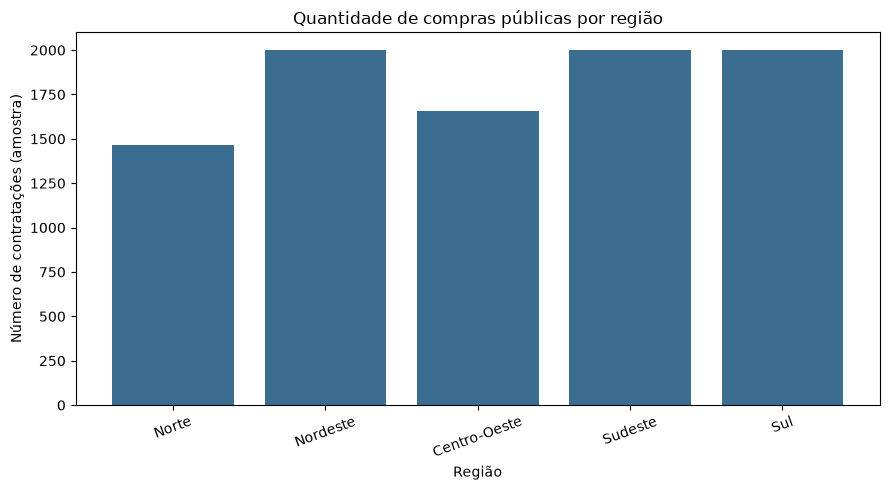

In [34]:
ordem_regiao = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]
resumo_plot = resumo_regiao.reindex(
    [r for r in ordem_regiao if r in resumo_regiao.index]
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(resumo_plot.index, resumo_plot["n_compras"], color="#3b6d91")
ax.set_title("Quantidade de compras públicas por região")
ax.set_xlabel("Região")
ax.set_ylabel("Número de contratações (amostra)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


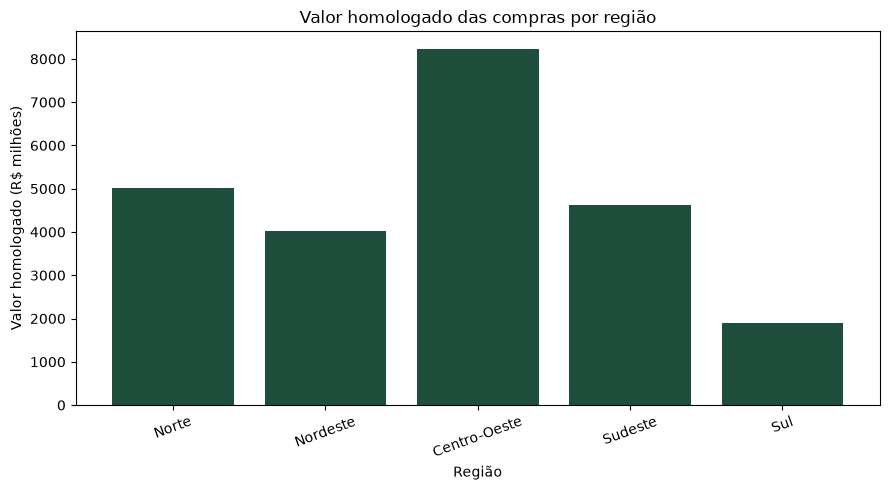

In [35]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    resumo_plot.index,
    resumo_plot["valor_homologado"] / 1_000_000,
    color="#1f4e3d",
)
ax.set_title("Valor homologado das compras por região")
ax.set_xlabel("Região")
ax.set_ylabel("Valor homologado (R$ milhões)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


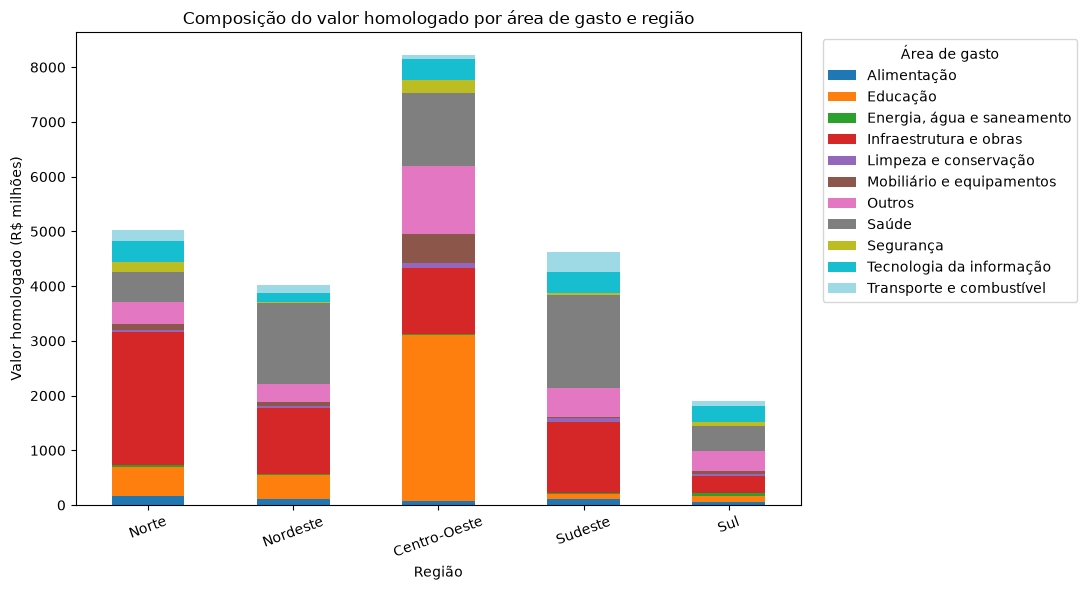

In [36]:
valor_area_regiao = (
    cruzamento_valor.reindex(index=[r for r in ordem_regiao if r in cruzamento_valor.index])
    / 1_000_000
)

fig, ax = plt.subplots(figsize=(11, 6))
valor_area_regiao.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_title("Composição do valor homologado por área de gasto e região")
ax.set_xlabel("Região")
ax.set_ylabel("Valor homologado (R$ milhões)")
ax.legend(title="Área de gasto", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


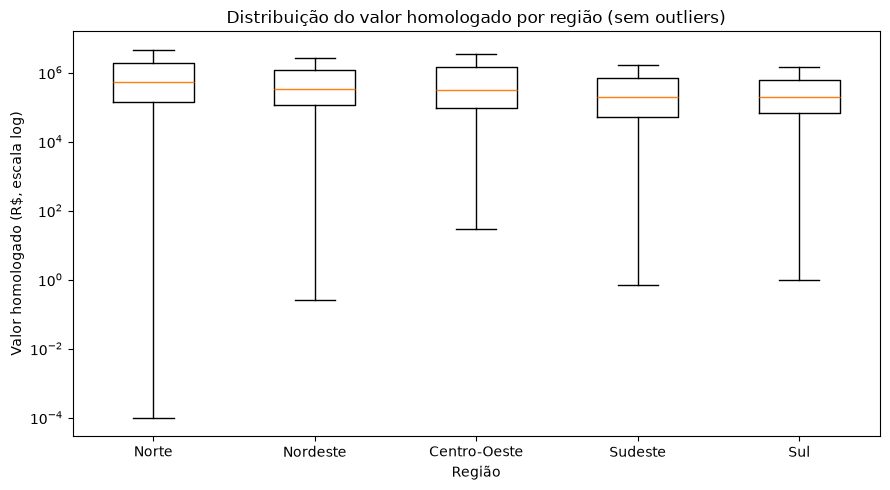

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))
dados_box = [
    df_valores.loc[df_valores["regiao"] == r, "valorTotalHomologado"].dropna()
    for r in ordem_regiao
    if r in set(df_valores["regiao"].dropna())
]
rotulos_box = [r for r in ordem_regiao if r in set(df_valores["regiao"].dropna())]

if dados_box:
    ax.boxplot(dados_box, showfliers=False)
    ax.set_xticklabels(rotulos_box)
    ax.set_yscale("log")
    ax.set_title("Distribuição do valor homologado por região (sem outliers)")
    ax.set_xlabel("Região")
    ax.set_ylabel("Valor homologado (R$, escala log)")
    plt.tight_layout()
    plt.show()
else:
    print("Sem dados de valor homologado para o boxplot.")


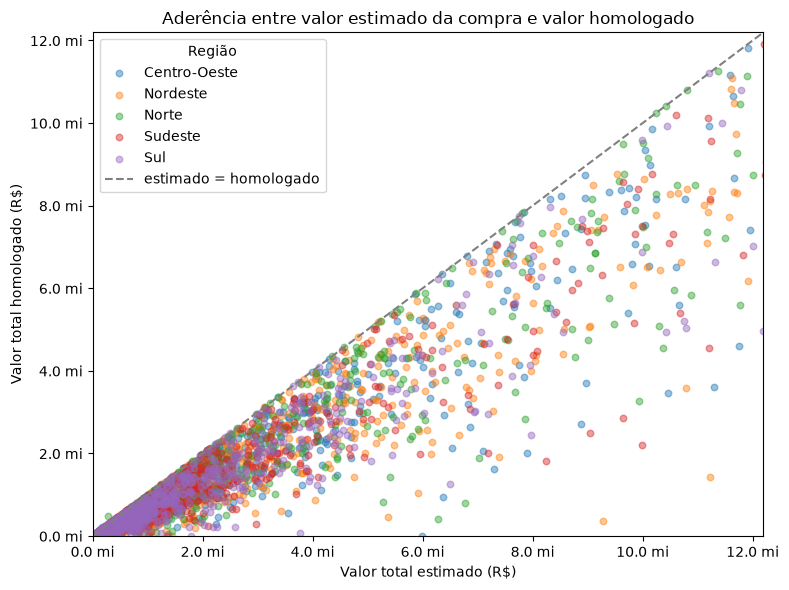

In [38]:
fig, ax = plt.subplots(figsize=(8, 6))

for regiao, bloco in df_valores.dropna(subset=["valorTotalEstimado", "valorTotalHomologado"]).groupby("regiao"):
    ax.scatter(
        bloco["valorTotalEstimado"],
        bloco["valorTotalHomologado"],
        alpha=0.45,
        label=regiao,
        s=22,
    )

limite = max(
    df_valores["valorTotalEstimado"].quantile(0.95),
    df_valores["valorTotalHomologado"].quantile(0.95),
)
ax.plot([0, limite], [0, limite], linestyle="--", color="gray", label="estimado = homologado")
ax.set_xlim(0, limite)
ax.set_ylim(0, limite)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f} mi"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f} mi"))
ax.set_title("Aderência entre valor estimado da compra e valor homologado")
ax.set_xlabel("Valor total estimado (R$)")
ax.set_ylabel("Valor total homologado (R$)")
ax.legend(title="Região")
plt.tight_layout()
plt.show()


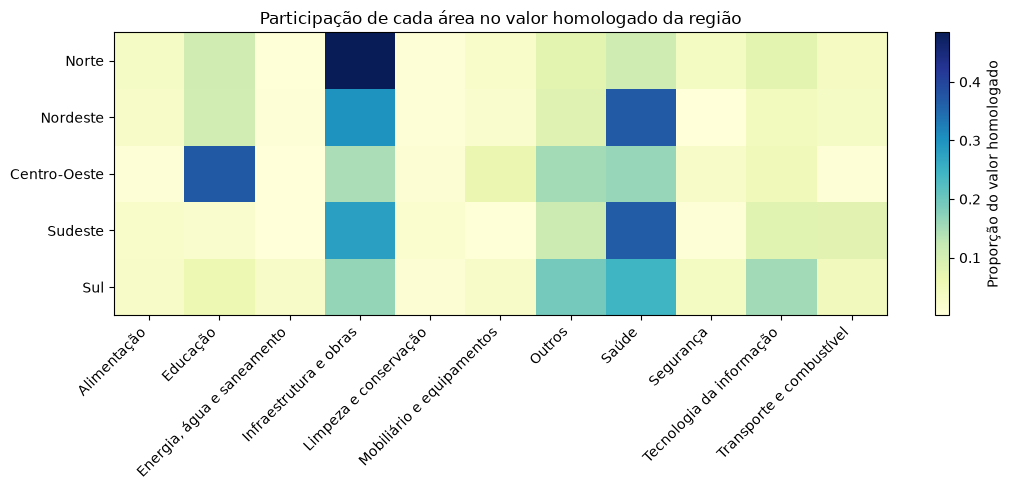

In [39]:
composicao = cruzamento_valor.div(cruzamento_valor.sum(axis=1).replace(0, np.nan), axis=0)
composicao = composicao.reindex(index=[r for r in ordem_regiao if r in composicao.index])

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(composicao.fillna(0).values, aspect="auto", cmap="YlGnBu")
ax.set_xticks(range(len(composicao.columns)))
ax.set_xticklabels(composicao.columns, rotation=45, ha="right")
ax.set_yticks(range(len(composicao.index)))
ax.set_yticklabels(composicao.index)
ax.set_title("Participação de cada área no valor homologado da região")
fig.colorbar(im, ax=ax, label="Proporção do valor homologado")
plt.tight_layout()
plt.show()


In [40]:
if not df_contratos.empty and "valorContrato" in df_contratos.columns:
    compras_org = (
        df_limpo.groupby(["regiao", "codigoOrgao"], as_index=False)
        .agg(
            valor_compras=("valorTotalHomologado", "sum"),
            n_compras=("idCompra", "count"),
        )
    )
    contratos_org = (
        df_contratos.dropna(subset=["codigoOrgao"])
        .groupby(["regiao", "codigoOrgao"], as_index=False)
        .agg(
            valor_contratos=("valorContrato", "sum"),
            n_contratos=("codigoOrgao", "count"),
        )
    )
    comparacao_orgaos = compras_org.merge(
        contratos_org,
        on=["regiao", "codigoOrgao"],
        how="inner",
    )

    comparacao_regiao = (
        comparacao_orgaos.groupby("regiao", as_index=False)[["valor_compras", "valor_contratos"]]
        .sum()
        .set_index("regiao")
        .reindex([r for r in ordem_regiao if r in set(comparacao_orgaos["regiao"])])
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(comparacao_regiao.index))
    largura = 0.38
    ax.bar(x - largura / 2, comparacao_regiao["valor_compras"] / 1_000_000, largura, label="Compras homologadas")
    ax.bar(x + largura / 2, comparacao_regiao["valor_contratos"] / 1_000_000, largura, label="Contratos")
    ax.set_xticks(x)
    ax.set_xticklabels(comparacao_regiao.index, rotation=20)
    ax.set_title("Compras homologadas e contratos nos órgãos amostrados, por região")
    ax.set_xlabel("Região")
    ax.set_ylabel("Valor (R$ milhões)")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Gráfico compras × contratos não gerado: DataFrame de contratos vazio ou sem coluna de valor.")
    comparacao_orgaos = pd.DataFrame()
    comparacao_regiao = pd.DataFrame()


Gráfico compras × contratos não gerado: DataFrame de contratos vazio ou sem coluna de valor.


## 15. Comparação quantitativa

Três comparações estruturam a resposta à pergunta de pesquisa:

1. **Regiões entre si** — quantidade, soma, mediana e teste de Kruskal-Wallis sobre o valor homologado.
2. **Compra versus contratação** — razão valor homologado / valor estimado, por região e por área.
3. **Compras versus contratos** — cruzamento por órgão/região, quando o módulo de contratos devolver registros.


In [41]:
print("Aderência homologado/estimado por região:")
display(resumo_regiao[["valor_estimado", "valor_homologado", "aderencia_homologado_estimado"]].round(3))

print("\nAderência homologado/estimado por área de gasto:")
display(resumo_area[["valor_estimado", "valor_homologado", "aderencia_homologado_estimado"]].round(3))

participacao_area = composicao.copy()

print("\nComposição percentual do valor homologado (região × área):")
display((participacao_area * 100).round(1))


Aderência homologado/estimado por região:


,valor_estimado,valor_homologado,aderencia_homologado_estimado
regiao,,,
Centro-Oeste,1.372017e+10,8.225494e+09,0.600
Norte,1.014212e+10,5.023819e+09,0.495
Sudeste,8.406695e+09,4.630908e+09,0.551
Nordeste,1.213352e+10,4.011661e+09,0.331
Sul,3.024208e+09,1.899488e+09,0.628



Aderência homologado/estimado por área de gasto:


,valor_estimado,valor_homologado,aderencia_homologado_estimado
area_gasto,,,
Infraestrutura e obras,1.437892e+10,6.440485e+09,0.448
Saúde,9.179003e+09,5.528567e+09,0.602
Educação,6.874631e+09,4.217473e+09,0.613
Outros,4.402587e+09,2.863641e+09,0.650
Tecnologia da informação,2.869951e+09,1.626980e+09,0.567
Transporte e combustível,1.144442e+09,8.592364e+08,0.751
Mobiliário e equipamentos,1.303908e+09,8.007179e+08,0.614
Segurança,8.715442e+08,5.303687e+08,0.609
Alimentação,1.002290e+09,5.205690e+08,0.519



Composição percentual do valor homologado (região × área):


area_gasto,Alimentação,Educação,"Energia, água e saneamento",Infraestrutura e obras,Limpeza e conservação,Mobiliário e equipamentos,Outros,Saúde,Segurança,Tecnologia da informação,Transporte e combustível
regiao,,,,,,,,,,,
Norte,3.2,10.8,0.5,48.4,0.6,2.5,7.9,11.0,3.6,7.7,3.8
Nordeste,3.0,10.6,0.8,29.9,0.8,1.9,8.4,36.8,0.2,4.4,3.3
Centro-Oeste,0.8,37.0,0.2,14.5,1.3,6.4,15.1,16.2,2.8,4.7,0.9
Sudeste,2.5,2.0,0.2,28.0,1.8,0.4,11.3,36.7,0.8,8.2,8.1
Sul,2.9,6.0,3.0,16.4,1.1,3.0,19.3,24.5,3.7,15.4,4.6


In [42]:
if SCIPY_OK:
    grupos = []
    nomes = []
    for regiao in ordem_regiao:
        serie = df_valores.loc[df_valores["regiao"] == regiao, "valorTotalHomologado"].dropna()
        if len(serie) >= 5:
            grupos.append(serie)
            nomes.append(regiao)

    if len(grupos) >= 2:
        estatistica, p_valor = stats.kruskal(*grupos)
        print("Kruskal-Wallis sobre o valor homologado entre regiões")
        print("Regiões testadas:", nomes)
        print("H =", round(estatistica, 4))
        print("p-valor =", p_valor)
    else:
        print("Amostra insuficiente para Kruskal-Wallis.")
else:
    print("scipy indisponível. Pule esta célula ou instale o pacote.")


scipy indisponível. Pule esta célula ou instale o pacote.


In [43]:
if not comparacao_orgaos.empty:
    print("Comparação compras × contratos nos órgãos amostrados:")
    display(comparacao_orgaos.round(2))

    if len(comparacao_orgaos) >= 5:
        corr = comparacao_orgaos["valor_compras"].corr(comparacao_orgaos["valor_contratos"])
        print("Correlação de Pearson (valor compras × valor contratos) =", round(corr, 3))

    comparacao_orgaos["razao_contrato_compra"] = (
        comparacao_orgaos["valor_contratos"] / comparacao_orgaos["valor_compras"].replace(0, np.nan)
    )
    print("\nRazão valor dos contratos / valor das compras, por região:")
    display(
        comparacao_orgaos.groupby("regiao")["razao_contrato_compra"]
        .median()
        .reindex(ordem_regiao)
        .round(3)
    )
else:
    print("Sem cruzamento compras × contratos nesta execução.")


Sem cruzamento compras × contratos nesta execução.


In [44]:
print("=== Síntese para discussão ===")
print("Período:", DATA_INICIAL, "a", DATA_FINAL)
print("Modalidade:", CODIGO_MODALIDADE)
print("UFs:", ", ".join(UFS_ANALISE))
print("Compras na amostra:", len(df_limpo))
print("Compras com homologação:", len(df_valores))
print("Contratos na amostra:", len(df_contratos))
print("\nÁrea mais frequente:", df_limpo["area_gasto"].value_counts().idxmax() if len(df_limpo) else "-")
if len(resumo_regiao):
    print("Região com maior valor homologado:", resumo_regiao["valor_homologado"].idxmax())
    print("Região com maior aderência homologado/estimado:", resumo_regiao["aderencia_homologado_estimado"].idxmax())


=== Síntese para discussão ===
Período: 2026-01-01 a 2026-06-30
Modalidade: 5
UFs: AM, PA, BA, PE, DF, GO, SP, MG, PR, RS
Compras na amostra: 9120
Compras com homologação: 7385
Contratos na amostra: 0

Área mais frequente: Saúde
Região com maior valor homologado: Centro-Oeste
Região com maior aderência homologado/estimado: Sul


## 16. Discussão

A discussão deve ser relida depois de executar as células. O encadeamento interpretativo é o seguinte.

**Diferenças regionais.** O gráfico de barras e a tabela da seção 13 mostram se o Sudeste concentra quantidade e valor, ou se alguma outra região se destaca na mediana (um número menor de compras de alto valor). Quantidade e valor podem contar histórias diferentes: muitas compras pequenas versus poucas compras grandes.

**Áreas de gasto.** O gráfico empilhado e o mapa de calor indicam se a composição setorial muda entre regiões. Se a hipótese H2 estiver correta, saúde, educação ou infraestrutura não terão o mesmo peso relativo no Norte e no Sudeste. A classificação por palavras-chave no objeto é aproximada: um mesmo processo pode misturar temas, e a categoria “Outros” tende a ser elevada.

**Compras e contratações “fazem sentido” entre si.** No diagrama de dispersão, pontos próximos à reta `estimado = homologado` sugerem aderência. Razões homologado/estimado muito abaixo de 1 indicam economia em relação à estimativa, orçamento sigiloso ainda sem resultado, ou homologação parcial. Razões próximas de 1, estáveis entre regiões, sustentam H3; razões muito heterogêneas por área sugerem que o desalinhamento é setorial, não apenas geográfico.

**Compras versus contratos.** O módulo de contratos não é um recorte censitário das mesmas compras: exige código de órgão, usa vigência (não publicação no PNCP) e cobre uma amostra de órgãos. Uma correlação positiva no cruzamento por órgão apoia H4, mas a ausência de correlação não invalida as compras — pode apenas refletir defasagem temporal entre licitar e contratar.

Não se infere causalidade. Região é um recorte geográfico da unidade compradora, não uma explicação isolada do gasto.


## 17. Limitações

- A API de contratações **exige modalidade**; a amostra não representa todas as modalidades da Lei 14.133/2021.
- Foram coletadas poucas páginas por UF: trata-se de amostra, não do universo do semestre.
- UFs representantes não esgotam cada região (por exemplo, o Norte não se reduz a AM e PA).
- `valorTotalHomologado` pode estar ausente (na consulta piloto, cerca de 16% em SP).
- A UF é da unidade compradora, o que não coincide necessariamente com o local de execução do objeto.
- A área de gasto é inferida por palavras-chave no texto de `objetoCompra`, sujeita a erro de classificação.
- O endpoint de contratos exige `codigoOrgao`; a comparação compras × contratos vale para órgãos amostrados, não para todas as UFs.
- Janelas de **publicação PNCP** e de **início de vigência** não descrevem o mesmo fato administrativo.
- Dados administrativos existem para gestão, não para experimento: associação não é causalidade.
- A disponibilidade da API, o tempo de resposta e o esquema de campos podem mudar.


## 18. Conclusão

O estudo descreve a distribuição regional das compras públicas no PNCP e verifica se esses gastos se alinham, por área temática, às contratações homologadas e, quando possível, aos contratos do mesmo órgão.

Depois de executar o notebook, a conclusão deve responder de forma direta:

1. Houve diferença relevante de volume ou de valor entre regiões?
2. As áreas de gasto pesam de modo distinto em cada região?
3. Valor estimado e valor homologado caminham juntos, ou há desalinhamento sistemático por região/área?
4. Nos órgãos em que foi possível cruzar os dois módulos, compras e contratos apontam na mesma direção?

Enquanto os resultados não forem gerados, as hipóteses H1–H4 permanecem como expectativas a serem confirmadas ou rejeitadas pelas tabelas e pelos gráficos das seções 13 a 15.

Fonte: [API Dados Abertos Compras.gov.br](https://dadosabertos.compras.gov.br/swagger-ui/index.html).


In [ ]:
PALAVRAS_PRODUTO = [
    "aquisicao", "aquisição", "compra de", "fornecimento de", "material",
    "medicamento", "vacina", "equipamento", "computador", "veiculo",
    "veículo", "mobiliario", "mobiliário", "alimento", "genero alimenticio",
    "gênero alimentício", "insumo", "peca", "peça", "produto",
]

PALAVRAS_SERVICO = [
    "servico", "serviço", "manutencao", "manutenção", "limpeza", "vigilancia",
    "vigilância", "seguranca", "segurança", "transporte", "consultoria",
    "assessoria", "locacao", "locação", "instalacao", "instalação",
    "reforma", "construcao", "construção", "engenharia", "suporte",
    "terceirizacao", "terceirização", "prestacao de servico",
    "prestação de serviço",
]


def classificar_tipo_contratacao(texto):
    if not isinstance(texto, str) or not texto.strip():
        return "Não identificado"

    texto_normalizado = texto.casefold()
    tem_produto = any(palavra.casefold() in texto_normalizado for palavra in PALAVRAS_PRODUTO)
    tem_servico = any(palavra.casefold() in texto_normalizado for palavra in PALAVRAS_SERVICO)

    if tem_produto and tem_servico:
        return "Misto"
    if tem_produto:
        return "Produto"
    if tem_servico:
        return "Serviço"
    return "Não identificado"


df_limpo["tipo_contratacao"] = (
    df_limpo["objetoCompra"].apply(classificar_tipo_contratacao)
    if "objetoCompra" in df_limpo.columns
    else "Não identificado"
)

df_valores["tipo_contratacao"] = (
    df_valores["objetoCompra"].apply(classificar_tipo_contratacao)
    if "objetoCompra" in df_valores.columns
    else "Não identificado"
)

print("Classificação dos registros:")
print(df_limpo["tipo_contratacao"].value_counts(dropna=False))

In [ ]:
regioes_plot = [r for r in ordem_regiao if r in df_limpo["regiao"].dropna().unique()]

for tipo, nome_tipo in [("Produto", "produtos"), ("Serviço", "serviços")]:
    dados_tipo = df_limpo[df_limpo["tipo_contratacao"] == tipo]
    quantidade_por_regiao = (
        dados_tipo.groupby("regiao")
        .size()
        .reindex(regioes_plot, fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(regioes_plot, quantidade_por_regiao.values, color="#3b6d91")
    ax.set_title(f"Quantidade de {nome_tipo} por região")
    ax.set_xlabel("Região")
    ax.set_ylabel("Número de contratações")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

for tipo, nome_tipo in [("Produto", "produtos"), ("Serviço", "serviços")]:
    dados_tipo = df_valores[df_valores["tipo_contratacao"] == tipo]
    valor_por_regiao = (
        dados_tipo.groupby("regiao")["valorTotalHomologado"]
        .sum()
        .reindex(regioes_plot, fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(regioes_plot, valor_por_regiao.values / 1_000_000, color="#1f4e3d")
    ax.set_title(f"Valor homologado de {nome_tipo} por região")
    ax.set_xlabel("Região")
    ax.set_ylabel("Valor homologado (R$ milhões)")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()